# Stock Market Quantative Analysis 
- Ticker: The stock ticker symbol.
- Date: The specific trading date.
- Open: Opening price of the stock for the day.
- High: Highest price point of the stock during the day.
- Low: Lowest price point during the day.
- Close: Closing price of the stock.
- Adj Close: Adjusted closing price, factoring in corporate actions like splits.
- Volume: Total trading volume of the stock.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
df = pd.read_csv("stocks.csv")
#df = pd.read_csv("/kaggle/input/stock-market-analysis/stocks.csv")

In [5]:
df.head(10)

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000
5,AAPL,2023-02-14,152.119995,153.770004,150.860001,153.199997,153.199997,61707600
6,AAPL,2023-02-15,153.110001,155.500000,152.880005,155.330002,155.330002,65573800
7,AAPL,2023-02-16,153.509995,156.330002,153.350006,153.710007,153.710007,68167900
8,AAPL,2023-02-17,152.350006,153.000000,150.850006,152.550003,152.550003,59144100
9,AAPL,2023-02-21,150.199997,151.300003,148.410004,148.479996,148.479996,58867200


In [6]:
df["Ticker"].unique()

array(['AAPL', 'MSFT', 'NFLX', 'GOOG'], dtype=object)

In [7]:
df.isnull().sum()

Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [8]:
df.Ticker.value_counts()

Ticker
AAPL    62
MSFT    62
NFLX    62
GOOG    62
Name: count, dtype: int64

In [9]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,248.000000,248.000000,248.000000,248.000000,248.000000,2.480000e+02
mean,215.252093,217.919662,212.697452,215.381674,215.362697,3.208210e+07
std,91.691315,92.863023,90.147881,91.461989,91.454750,2.233590e+07
min,89.540001,90.129997,88.860001,89.349998,89.349998,2.657900e+06
25%,135.235004,137.440004,134.822495,136.347498,136.347498,1.714180e+07
50%,208.764999,212.614998,208.184998,209.920006,209.920006,2.734000e+07
75%,304.177505,307.565002,295.437500,303.942505,303.942505,4.771772e+07
max,372.410004,373.829987,361.739990,366.829987,366.829987,1.133164e+08


In [13]:
df.columns = df.columns.str.strip()

In [14]:
df['Date'] = pd.to_datetime(df['Date'])

In [15]:
df = df.sort_values(by=['Ticker','Date'])

In [16]:
df['Adj Close'] = pd.to_numeric(df['Adj Close'], errors='coerce')

In [17]:
df['Return'] = df.groupby('Ticker')['Adj Close'].pct_change()

In [18]:
df[['Ticker','Date','Adj Close','Return']].head(20)

,Ticker,Date,Adj Close,Return
0,AAPL,2023-02-07,154.414230,NaN
1,AAPL,2023-02-08,151.688400,-0.017653
2,AAPL,2023-02-09,150.639999,-0.006912
3,AAPL,2023-02-10,151.009995,0.002456
4,AAPL,2023-02-13,153.850006,0.018807
5,AAPL,2023-02-14,153.199997,-0.004225
6,AAPL,2023-02-15,155.330002,0.013903
7,AAPL,2023-02-16,153.710007,-0.010429
8,AAPL,2023-02-17,152.550003,-0.007547
9,AAPL,2023-02-21,148.479996,-0.026680


## Moving Average

In [20]:
df = df.sort_values(by=['Ticker','Date'])

In [21]:
df['MA50'] = df.groupby('Ticker')['Adj Close'].transform(lambda x: x.rolling(50, min_periods=1).mean())
df['MA200'] = df.groupby('Ticker')['Adj Close'].transform(lambda x: x.rolling(200, min_periods=1).mean())

In [22]:
df = df.sort_values(by=['Ticker','Date'])

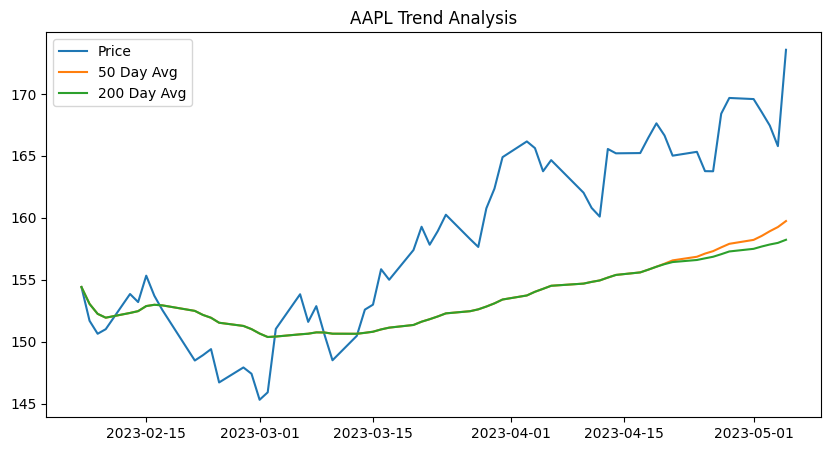

In [25]:
df_TA = df[df['Ticker']=='AAPL']
plt.figure(figsize=(10,5))

plt.plot(df_TA['Date'], df_TA['Adj Close'], label='Price')
plt.plot(df_TA['Date'], df_TA['MA50'], label='50 Day Avg')
plt.plot(df_TA['Date'], df_TA['MA200'], label='200 Day Avg')

plt.title("AAPL Trend Analysis")
plt.legend()
plt.show()


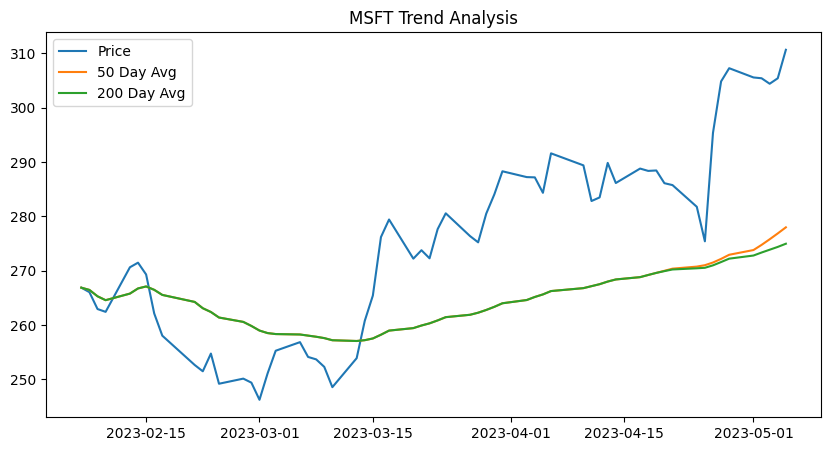

In [26]:
df_TA = df[df['Ticker']=='MSFT']
plt.figure(figsize=(10,5))

plt.plot(df_TA['Date'], df_TA['Adj Close'], label='Price')
plt.plot(df_TA['Date'], df_TA['MA50'], label='50 Day Avg')
plt.plot(df_TA['Date'], df_TA['MA200'], label='200 Day Avg')

plt.title("MSFT Trend Analysis")
plt.legend()
plt.show()


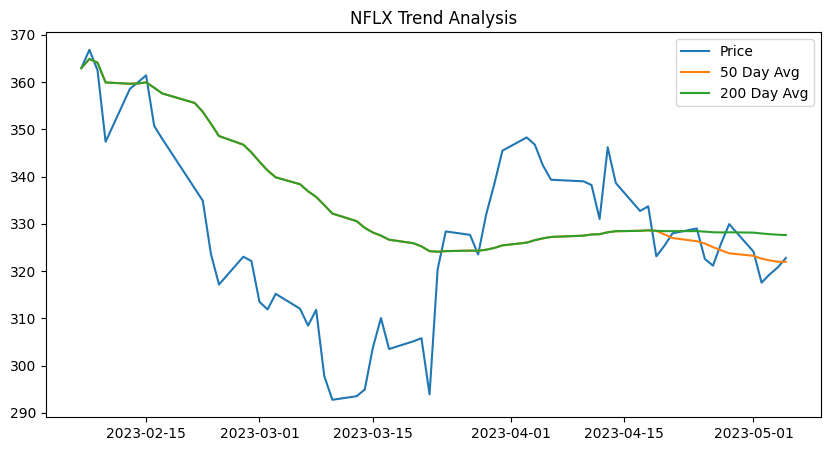

In [27]:
df_TA = df[df['Ticker']=='NFLX']
plt.figure(figsize=(10,5))

plt.plot(df_TA['Date'], df_TA['Adj Close'], label='Price')
plt.plot(df_TA['Date'], df_TA['MA50'], label='50 Day Avg')
plt.plot(df_TA['Date'], df_TA['MA200'], label='200 Day Avg')

plt.title("NFLX Trend Analysis")
plt.legend()
plt.show()


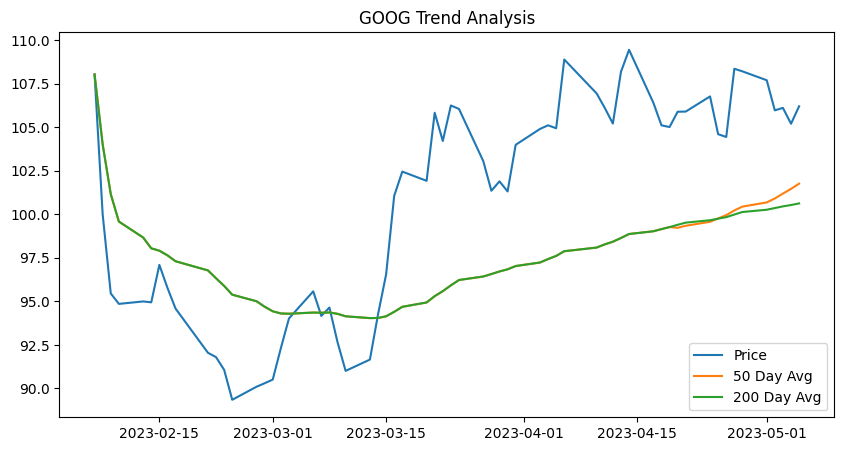

In [28]:
df_TA = df[df['Ticker']=='GOOG']
plt.figure(figsize=(10,5))

plt.plot(df_TA['Date'], df_TA['Adj Close'], label='Price')
plt.plot(df_TA['Date'], df_TA['MA50'], label='50 Day Avg')
plt.plot(df_TA['Date'], df_TA['MA200'], label='200 Day Avg')

plt.title("GOOG Trend Analysis")
plt.legend()
plt.show()


In [29]:
pivot = df.pivot(index='Date', columns='Ticker', values='Adj Close')

normalized = pivot / pivot.iloc[0] * 100

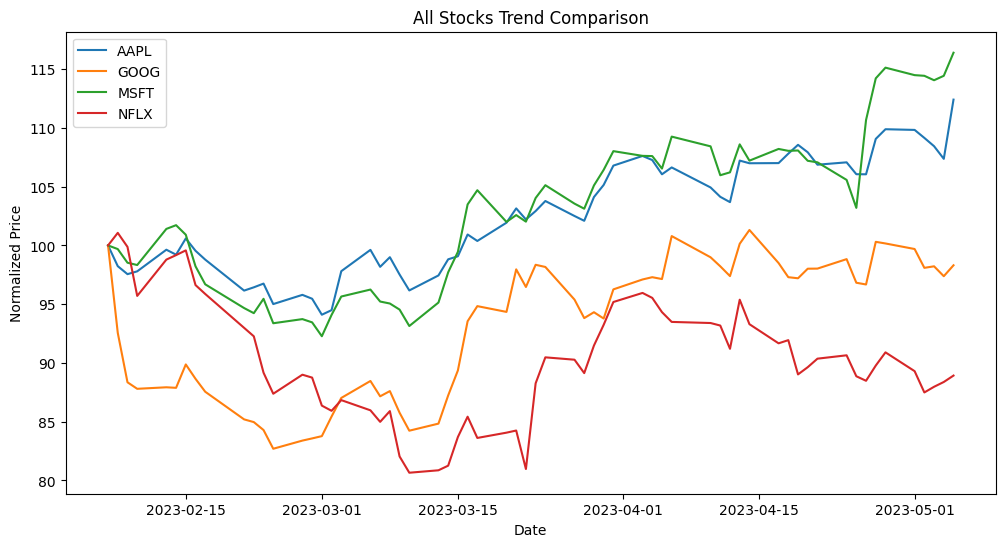

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for column in normalized.columns:
    plt.plot(normalized.index, normalized[column], label=column)

plt.title('All Stocks Trend Comparison')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.show()

In [31]:
final_values = normalized.iloc[-1]
best_stock = final_values.idxmax()

print("Best Performing Stock:", best_stock)

Best Performing Stock: MSFT
